# IT5006 - Operational Capacity EDA
## Delivery Timing, Capacity Strain & Fulfilment Pipeline Analysis

**Contributor:** Chai Winnie
**Extends:** `IT5006-Olist_Getting_Started.ipynb` (continues from the consolidated dataset built in that notebook's Section 3)

This notebook explores whether delivery delay is purely a per-order attribute, or partly a
**capacity/throughput problem** that shows up in operational patterns: weekly volume, purchase
timing, freight economics, backlog, and how Olist's own delivery promise behaves under load.
These findings feed the team's candidate problem: predicting delivery lead time (regression) and
classifying orders as late vs. on-time (classification).

---
## 1. Environment Setup & Data Loading

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

pandas: 3.0.5
numpy: 2.4.6


In [2]:
# === DATA PATH CONFIGURATION ===
# Option 1: Google Colab with Drive
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = "/content/drive/MyDrive/2026_work/IS5126/Olist"

# Option 2: cloned GitHub repo (recommended if running fresh in Colab)
# !git clone https://github.com/YuanJiayi/IT5006_Grp_6.git
# DATA_DIR = "IT5006_Grp_6/data"

# Option 3: local path
DATA_DIR = "./data"  # adjust as needed

if os.path.exists(DATA_DIR):
    print(f"Data directory found: {DATA_DIR}")
else:
    print(f"Data directory not found: {DATA_DIR}")
    print("Please update DATA_DIR to point to your Olist data folder")

Data directory found: ./data


In [3]:
# Load the tables this notebook needs into a dictionary of DataFrames,
# same pattern as the starter notebook's load_olist_data()
def load_capacity_data(data_dir):
    """Load the consolidated dataset plus the raw orders table (for
    approval/carrier timestamps not present in the consolidated file)."""

    tables = {
        'consolidated': 'smartcommerce_consolidated.csv',
        'orders': 'olist_orders_dataset.csv',
    }

    date_cols = {
        'consolidated': ['order_purchase_timestamp', 'order_delivered_customer_date',
                          'order_estimated_delivery_date'],
        'orders': ['order_purchase_timestamp', 'order_approved_at',
                   'order_delivered_carrier_date', 'order_delivered_customer_date'],
    }

    data = {}
    for name, filename in tables.items():
        filepath = os.path.join(data_dir, filename)
        parse_dates = date_cols.get(name, None)
        data[name] = pd.read_csv(filepath, parse_dates=parse_dates)
        print(f"Loaded {name}: {data[name].shape[0]:,} rows x {data[name].shape[1]} cols")

    return data

olist = load_capacity_data(DATA_DIR)

Loaded consolidated: 112,650 rows x 25 cols


Loaded orders: 99,441 rows x 8 cols


---
## 2. Preparing the Analysis Dataset

The consolidated file already has order-level fields (`delivery_days`, `is_on_time`,
`day_of_week`, price, freight, category). It does **not** have `order_approved_at` or
`order_delivered_carrier_date` (needed to break lead time into processing / handling /
shipping stages), so those two columns are merged in from the raw orders table.

In [4]:
line_items = olist['consolidated']
orders_raw = olist['orders']

TREND_START = pd.Timestamp('2017-01-01')
TREND_END = pd.Timestamp('2018-09-01')

def eligible_deliveries(order_data):
    """Orders with a delivered status and both dates needed for lead-time analysis."""
    return order_data.loc[
        order_data['order_status'].eq('delivered')
        & order_data['order_delivered_customer_date'].notna()
        & order_data['order_estimated_delivery_date'].notna()
    ].copy()

def trim_trend_window(data, date_column):
    return data.loc[data[date_column].ge(TREND_START) & data[date_column].lt(TREND_END)].copy()

orders = line_items.drop_duplicates('order_id')
print(f"Orders (deduped from line items): {len(orders):,}")

eligible = eligible_deliveries(orders)
print(f"Eligible for lead-time analysis (delivered, complete timestamps): {len(eligible):,} "
      f"({len(eligible) / len(orders) * 100:.1f}% of orders)")

Orders (deduped from line items): 98,666


Eligible for lead-time analysis (delivered, complete timestamps): 96,470 (97.8% of orders)


In [5]:
# Merge in the two extra timestamps needed for stage decomposition
STAGE_LABELS = {
    'processing_time': 'Processing (purchase to approval)',
    'handling_time': 'Handling (approval to carrier)',
    'shipping_time': 'Shipping (carrier to customer)',
}
STAGE_KEYS = list(STAGE_LABELS.keys())

stage_cols = ['order_id', 'order_approved_at', 'order_delivered_carrier_date']
stages = orders.merge(orders_raw[stage_cols], on='order_id', how='left')

stages['processing_time'] = (stages['order_approved_at'] - stages['order_purchase_timestamp']).dt.total_seconds() / 86_400
stages['handling_time'] = (stages['order_delivered_carrier_date'] - stages['order_approved_at']).dt.total_seconds() / 86_400
stages['shipping_time'] = (stages['order_delivered_customer_date'] - stages['order_delivered_carrier_date']).dt.total_seconds() / 86_400

# Isolate the two distinct exclusion reasons separately, rather than lumping them together
has_all_4 = stages[['order_approved_at', 'order_delivered_carrier_date',
                     'order_purchase_timestamp', 'order_delivered_customer_date']].notna().all(axis=1)
missing_timestamp_orders = (~has_all_4).sum()

has_both_compared = stages[['order_approved_at', 'order_delivered_carrier_date']].notna().all(axis=1)
carrier_before_approval = (stages.loc[has_both_compared, 'handling_time'] < 0).sum()

valid_stage_mask = has_all_4 & stages[STAGE_KEYS].ge(0).all(axis=1)
stage_clean = stages.loc[valid_stage_mask].copy()

print(f"Orders missing at least one of the 4 required timestamps: {missing_timestamp_orders:,}")
print(f"Orders with carrier handoff recorded before approval: {carrier_before_approval:,} "
      f"(of {has_both_compared.sum():,} with both timestamps present)")
print(f"Orders with valid, complete, non-negative stage durations: {len(stage_clean):,} "
      f"({len(stage_clean) / len(stages) * 100:.1f}% of all orders)")


Orders missing at least one of the 4 required timestamps: 2,205
Orders with carrier handoff recorded before approval: 1,359 (of 97,643 with both timestamps present)
Orders with valid, complete, non-negative stage durations: 95,088 (96.4% of all orders)


**Data quality note:** 1,359 orders have `order_delivered_carrier_date` recorded *before*
`order_approved_at` — a timestamp-logging inconsistency in the source data, not a bug in this
analysis. These are excluded only from stage-decomposition charts (where a negative duration
would be meaningless), and retained everywhere else.

---
## 3. Capacity Strain: Weekly Order Volume vs. Delivery Time

**Question:** Does delivery slow down when order volume spikes, i.e. is delay partly a
capacity/throughput problem rather than purely a per-order attribute?

In [6]:
weekly_trimmed = trim_trend_window(eligible, 'order_purchase_timestamp')
weekly_trimmed = weekly_trimmed.assign(
    period=weekly_trimmed['order_purchase_timestamp'].dt.to_period('W').dt.start_time
)
capacity_series = weekly_trimmed.groupby('period', as_index=False).agg(
    orders=('order_id', 'nunique'),
    median_delivery_days=('delivery_days', 'median'),
)

corr = capacity_series['orders'].corr(capacity_series['median_delivery_days'])
peak_volume_week = capacity_series.loc[capacity_series['orders'].idxmax()]
peak_delay_week = capacity_series.loc[capacity_series['median_delivery_days'].idxmax()]

print(f"Correlation (weekly volume, median delivery days): r = {corr:.2f}")
print(f"Peak volume week: {peak_volume_week['period'].date()} -> {peak_volume_week['orders']:.0f} orders, "
      f"{peak_volume_week['median_delivery_days']:.0f}-day median")
print(f"Peak delay week:  {peak_delay_week['period'].date()} -> {peak_delay_week['orders']:.0f} orders, "
      f"{peak_delay_week['median_delivery_days']:.0f}-day median")

Correlation (weekly volume, median delivery days): r = 0.12
Peak volume week: 2017-11-20 -> 2915 orders, 13-day median
Peak delay week:  2018-01-29 -> 1561 orders, 15-day median


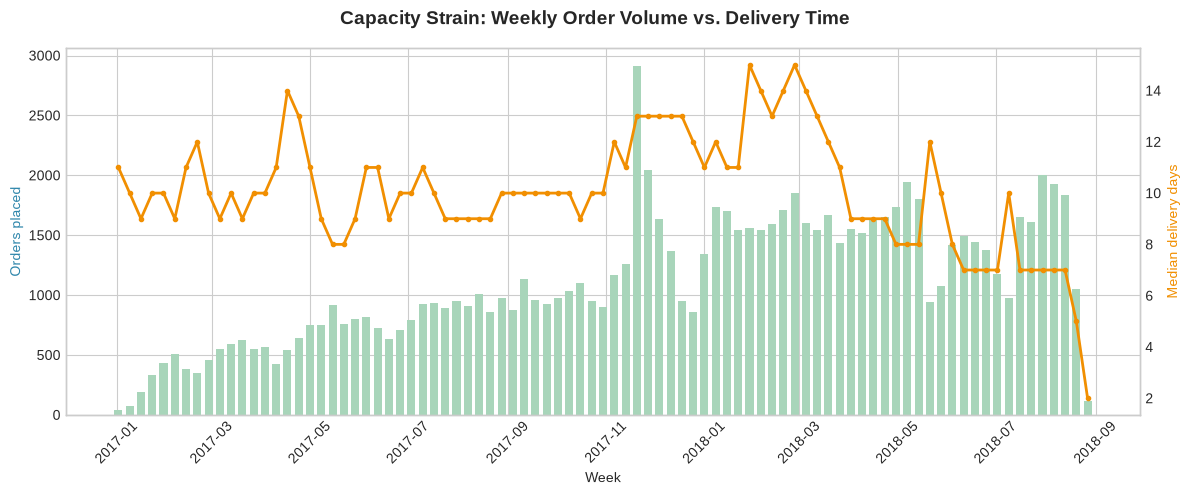

In [7]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(12, 5))
fig.suptitle('Capacity Strain: Weekly Order Volume vs. Delivery Time', fontsize=14, fontweight='bold')

ax1.bar(capacity_series['period'], capacity_series['orders'], width=5, color='#A8D5BA', label='Orders placed')
ax1.set_xlabel('Week')
ax1.set_ylabel('Orders placed', color='#2E86AB')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(capacity_series['period'], capacity_series['median_delivery_days'], color='#F18F01', linewidth=2, marker='o', markersize=3)
ax2.set_ylabel('Median delivery days', color='#F18F01')
ax2.grid(False)

plt.tight_layout()
plt.show()

**Finding:** Weekly order volume and delivery time show only a weak correlation (r &asymp; 0.12).
The worst-delay week (15-day median) wasn't even the highest-volume week. The Nov-Dec 2017 demand
spike produced a *sustained* elevation in delivery time (11-13 days across six weeks) rather than
an instant spike-and-recover, suggesting the system doesn't fail during the spike itself so much
as it takes weeks to work through the resulting backlog.

---
## 4. Purchase Timing: Day-of-Week x Hour Heatmap

**Question:** Is the moment an order is placed (day/hour) informative about delivery time, even
though it's a free, always-available feature at order time?

In [8]:
DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heat_data = eligible.assign(purchase_hour=eligible['order_purchase_timestamp'].dt.hour)
heatmap = heat_data.groupby(['day_of_week', 'purchase_hour'])['delivery_days'].mean().unstack()
heatmap = heatmap.reindex(DAY_ORDER)

by_day = heat_data.groupby('day_of_week')['delivery_days'].mean().reindex(DAY_ORDER).sort_values()
print("Mean delivery days by purchase day-of-week:")
print(by_day.round(2))

Mean delivery days by purchase day-of-week:
day_of_week
Sunday      11.47
Monday      11.53
Tuesday     11.61
Wednesday   11.98
Thursday    12.28
Saturday    12.89
Friday      13.12
Name: delivery_days, dtype: float64


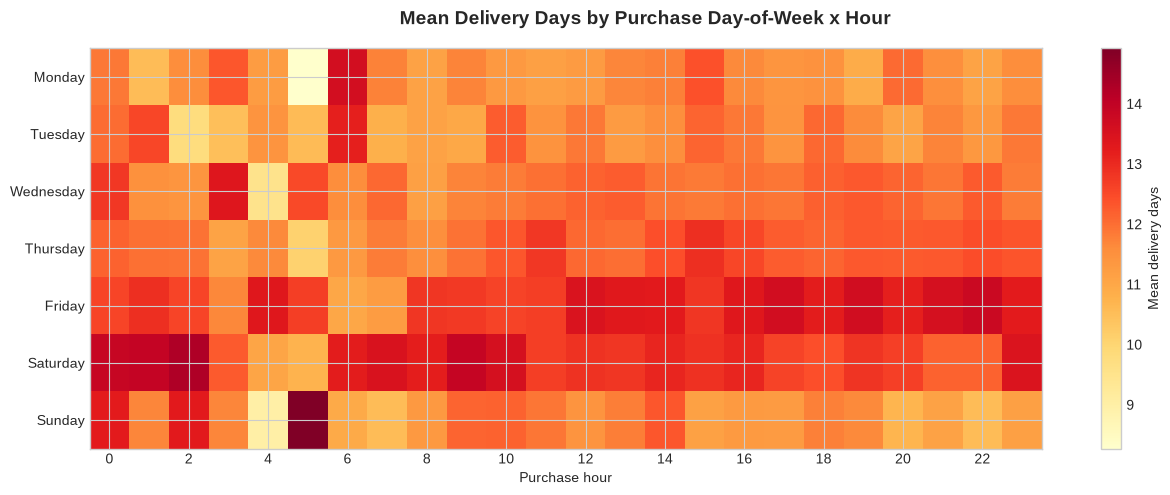

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle('Mean Delivery Days by Purchase Day-of-Week x Hour', fontsize=14, fontweight='bold')

im = ax.imshow(heatmap.values, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(DAY_ORDER)))
ax.set_yticklabels(DAY_ORDER)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels(range(0, 24, 2))
ax.set_xlabel('Purchase hour')
fig.colorbar(im, ax=ax, label='Mean delivery days')

plt.tight_layout()
plt.show()

**Finding:** Sunday purchases average the fastest delivery (11.5 days), Friday the slowest
(13.1 days) &mdash; a 1.6-day gap from timing alone. The slowest cells cluster around Friday evening
and Saturday morning; the fastest cluster around Sunday evening and Monday morning, consistent
with orders placed right before the weekend sitting idle until processing resumes.

---
## 5. Which Fulfilment Stage Slows Down for Weekend Purchases?

**Question:** Decomposing the day-of-week effect above into processing / handling / shipping,
does it concentrate in one specific stage?

In [10]:
stage_clean_dow = stage_clean.assign(
    day_of_week=stage_clean['order_purchase_timestamp'].dt.day_name()
)
by_weekday_stage = stage_clean_dow.groupby('day_of_week')[STAGE_KEYS].mean().reindex(DAY_ORDER)
print(by_weekday_stage.round(2))

             processing_time  handling_time  shipping_time
day_of_week                                               
Monday                  0.36           2.38           9.31
Tuesday                 0.34           2.53           9.28
Wednesday               0.34           2.68           9.51
Thursday                0.35           3.04           9.40
Friday                  0.51           3.71           9.38
Saturday                0.56           3.33           9.53
Sunday                  0.41           2.45           9.16


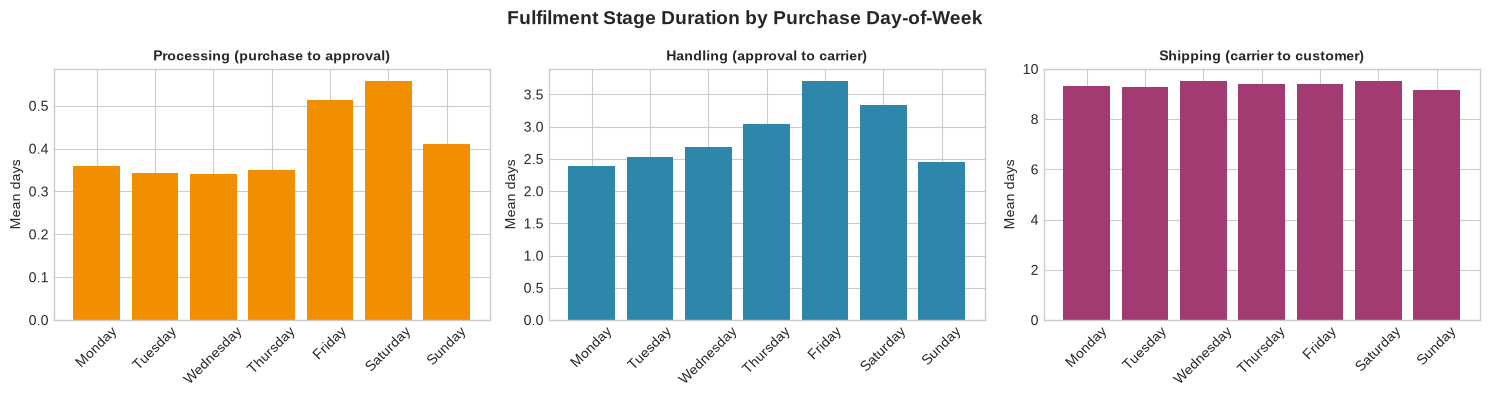

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Fulfilment Stage Duration by Purchase Day-of-Week', fontsize=14, fontweight='bold')
stage_colors = ['#F18F01', '#2E86AB', '#A23B72']

for ax, stage_key, color in zip(axes, STAGE_KEYS, stage_colors):
    ax.bar(DAY_ORDER, by_weekday_stage[stage_key], color=color)
    ax.set_title(STAGE_LABELS[stage_key], fontweight='bold', fontsize=10)
    ax.set_ylabel('Mean days')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Finding:** The weekend slowdown comes almost entirely from the **handling** stage
(approval to carrier pickup): 3.0-3.7 days for Thursday-Saturday purchases vs. 2.4-2.7 days for
Sunday-Wednesday. Shipping time (carrier to customer) stays flat at 9.2-9.5 days regardless of
purchase day. This confirms the slowdown is a warehouse/fulfilment queue issue, not a shipping
or carrier issue.

---
## 6. Freight Cost Efficiency: Freight-to-Price Ratio vs. Late-Rate

**Question:** Does a composite ratio combining distance, weight and carrier pricing (freight
value / price) predict lateness?

In [12]:
order_economics = line_items.groupby('order_id', as_index=False).agg(
    price_sum=('price', 'sum'), freight_sum=('freight_value', 'sum')
)
order_status_cols = line_items.drop_duplicates('order_id')[
    ['order_id', 'order_status', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_on_time']
]
freight_data = order_economics.merge(order_status_cols, on='order_id', how='left')
freight_data = eligible_deliveries(freight_data)
freight_data = freight_data.loc[freight_data['price_sum'] > 0].copy()
freight_data['freight_ratio'] = freight_data['freight_sum'] / freight_data['price_sum']
freight_data['late'] = ~freight_data['is_on_time'].astype(bool)
freight_data['ratio_bucket'] = pd.qcut(freight_data['freight_ratio'], 6, duplicates='drop')

freight_buckets = freight_data.groupby('ratio_bucket', observed=True).agg(
    late_rate=('late', 'mean'), orders=('order_id', 'size')
).reset_index()
freight_buckets['late_rate'] *= 100
freight_buckets['label'] = freight_buckets['ratio_bucket'].apply(lambda i: f"{max(i.left, 0):.2f}-{i.right:.2f}")
print(freight_buckets[['label', 'late_rate', 'orders']].round(2))

        label  late_rate  orders
0   0.00-0.10       8.33   16080
1   0.10-0.16       7.92   16077
2   0.16-0.22       7.80   16099
3   0.22-0.31       8.03   16057
4   0.31-0.49       8.17   16078
5  0.49-21.45       8.41   16079


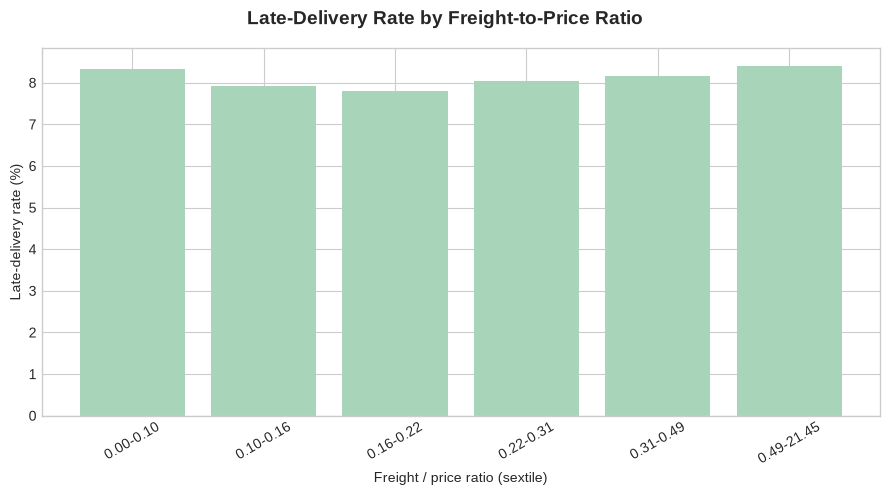

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Late-Delivery Rate by Freight-to-Price Ratio', fontsize=14, fontweight='bold')
ax.bar(freight_buckets['label'], freight_buckets['late_rate'], color='#A8D5BA')
ax.set_xlabel('Freight / price ratio (sextile)')
ax.set_ylabel('Late-delivery rate (%)')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Finding:** Late-rate stays roughly flat across all six buckets (about 7.8-8.4%). Despite
bundling distance, weight and carrier pricing into one number, this ratio alone isn't a strong
standalone predictor of lateness &mdash; a useful negative result for feature selection in Phase 2.

---
## 7. Backlog: Orders Placed vs. Delivered Over Time

**Question:** Does a cumulative gap between orders placed and orders delivered build up during
high-volume periods, and how long does it take to clear?

In [14]:
placed = weekly_trimmed.groupby('period').size()
placed.name = 'placed'

completed_data = weekly_trimmed.assign(
    completed_period=weekly_trimmed['order_delivered_customer_date'].dt.to_period('W').dt.start_time
)
completed = completed_data.groupby('completed_period').size()
completed.name = 'completed'

backlog = pd.concat([placed, completed], axis=1).fillna(0)
full_index = pd.date_range(backlog.index.min(), backlog.index.max(), freq='W-MON')
backlog = backlog.reindex(full_index, fill_value=0)
backlog.index.name = 'period'
backlog = backlog.reset_index()
backlog['backlog'] = (backlog['placed'] - backlog['completed']).cumsum()

peak_backlog = backlog.loc[backlog['backlog'].idxmax()]
print(f"Peak backlog: {peak_backlog['backlog']:.0f} orders, week of {peak_backlog['period'].date()}")

Peak backlog: 4429 orders, week of 2017-11-27


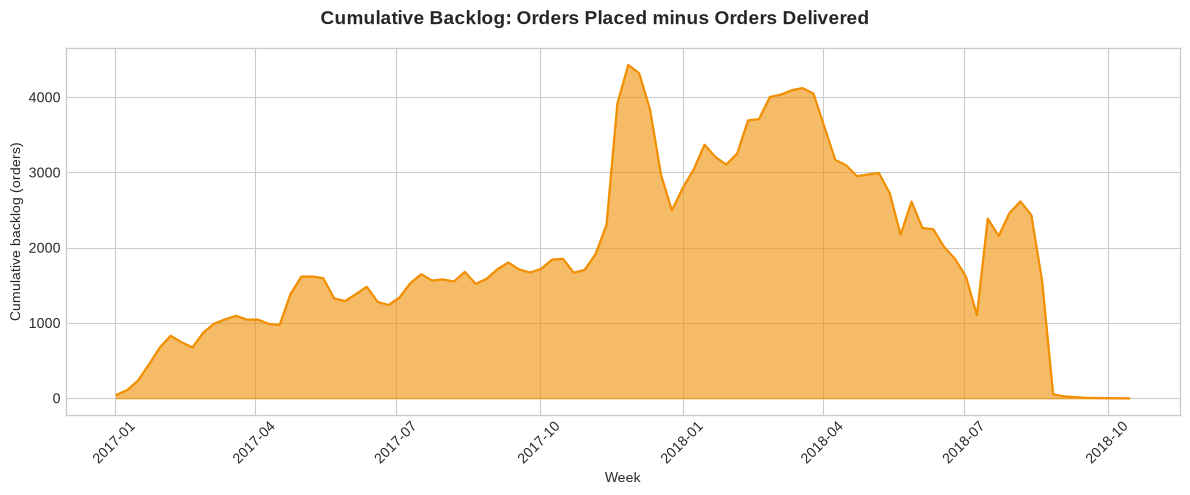

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Cumulative Backlog: Orders Placed minus Orders Delivered', fontsize=14, fontweight='bold')
ax.fill_between(backlog['period'], backlog['backlog'], color='#F18F01', alpha=0.6)
ax.plot(backlog['period'], backlog['backlog'], color='#F18F01', linewidth=1.5)
ax.set_xlabel('Week')
ax.set_ylabel('Cumulative backlog (orders)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Finding:** Backlog peaked at 4,429 orders in the week of Nov 27, 2017 &mdash; a week *after*
the volume peak, showing backlog builds up and takes time to clear even after demand drops.
Backlog also stayed elevated (1,100-2,600+ orders) during non-holiday periods in mid-2018,
suggesting this is a recurring operational condition rather than a one-off holiday effect.
(Caveat: the final few weeks are inflated by right-censoring, since recently placed orders
haven't had time to be delivered yet as of the data snapshot.)

---
## 8. Does Olist's Own Delivery Promise React to Capacity Strain?

**Question:** Is the "late" label stable over time, or does the promised delivery window itself
drift &mdash; which would mean the classification target for Phase 2 needs careful definition?

In [16]:
promise_data = weekly_trimmed.assign(
    promised_days=(weekly_trimmed['order_estimated_delivery_date'] - weekly_trimmed['order_purchase_timestamp']).dt.total_seconds() / 86_400,
    actual_days=(weekly_trimmed['order_delivered_customer_date'] - weekly_trimmed['order_purchase_timestamp']).dt.total_seconds() / 86_400,
    late=weekly_trimmed['order_delivered_customer_date'] > weekly_trimmed['order_estimated_delivery_date'],
)
promise_series = promise_data.groupby('period', as_index=False).agg(
    mean_promised_days=('promised_days', 'mean'),
    mean_actual_days=('actual_days', 'mean'),
    late_rate=('late', 'mean'),
)
promise_series['late_rate'] *= 100
promise_series['buffer_days'] = promise_series['mean_promised_days'] - promise_series['mean_actual_days']

corr_promise_late = promise_series['buffer_days'].corr(promise_series['late_rate'])
print(f"Correlation (buffer_days, late_rate): r = {corr_promise_late:.2f}")

trailing_8wk = promise_series['mean_actual_days'].rolling(8).mean().shift(1)
corr_trailing = promise_series['mean_promised_days'].corr(trailing_8wk)
print(f"Correlation (promised_days, 8-week trailing actual_days): r = {corr_trailing:.2f}")

Correlation (buffer_days, late_rate): r = -0.64
Correlation (promised_days, 8-week trailing actual_days): r = 0.45


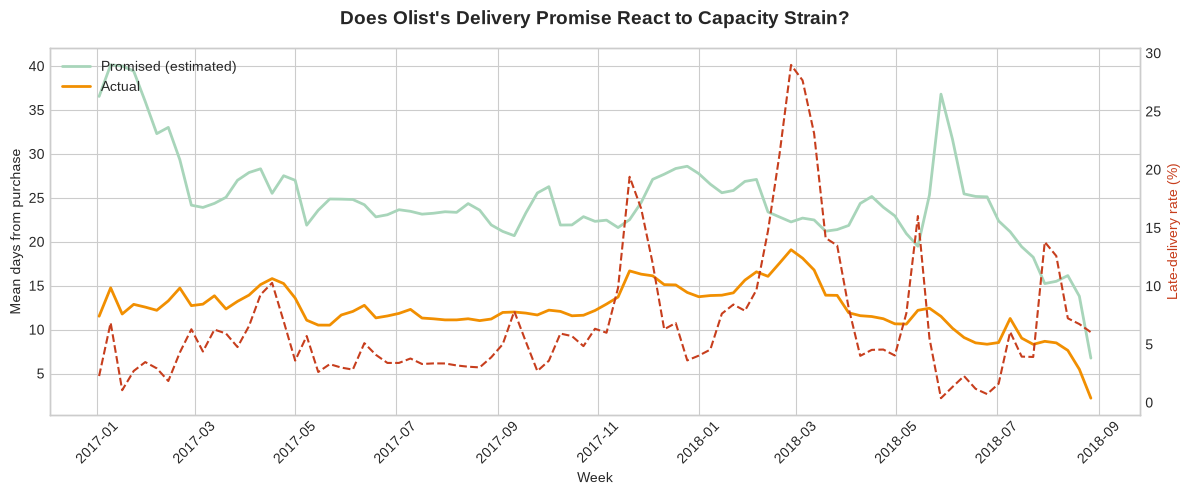

In [17]:
fig, ax1 = plt.subplots(figsize=(12, 5))
fig.suptitle("Does Olist's Delivery Promise React to Capacity Strain?", fontsize=14, fontweight='bold')

ax1.plot(promise_series['period'], promise_series['mean_promised_days'], color='#A8D5BA', linewidth=2, label='Promised (estimated)')
ax1.plot(promise_series['period'], promise_series['mean_actual_days'], color='#F18F01', linewidth=2, label='Actual')
ax1.set_xlabel('Week')
ax1.set_ylabel('Mean days from purchase')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(promise_series['period'], promise_series['late_rate'], color='#C73E1D', linewidth=1.5, linestyle='--', label='Late-delivery rate (%)')
ax2.set_ylabel('Late-delivery rate (%)', color='#C73E1D')
ax2.grid(False)

plt.tight_layout()
plt.show()

**Finding:** The promised window widens with a lag after volume spikes (it barely moves
during the Nov 2017 peak week itself, but keeps climbing for weeks afterward). It correlates more
with a several-week trailing average of actual delivery performance than with current-week
backlog, suggesting a slow-reacting historical baseline rather than a live capacity signal.
Since the late/on-time label is defined relative to this promise, a wider promise can lower the
late-rate even if actual delivery isn't getting faster &mdash; a methodological note worth carrying
into how the classification target is defined in Phase 2.

---
## 9. Where Does the Delay Accumulate? Stage Duration Over Time

In [18]:
stage_weekly = trim_trend_window(stage_clean, 'order_purchase_timestamp').assign(
    period=lambda d: d['order_purchase_timestamp'].dt.to_period('W').dt.start_time
)
stage_over_time = stage_weekly.groupby('period')[STAGE_KEYS].mean()

overall_mean = stage_clean[STAGE_KEYS].mean()
print("Overall mean duration per stage (days):")
print(overall_mean.round(2))
print(f"\nShipping share of total lead time: {overall_mean['shipping_time'] / overall_mean.sum() * 100:.0f}%")

Overall mean duration per stage (days):
processing_time   0.40
handling_time     2.85
shipping_time     9.36
dtype: float64

Shipping share of total lead time: 74%


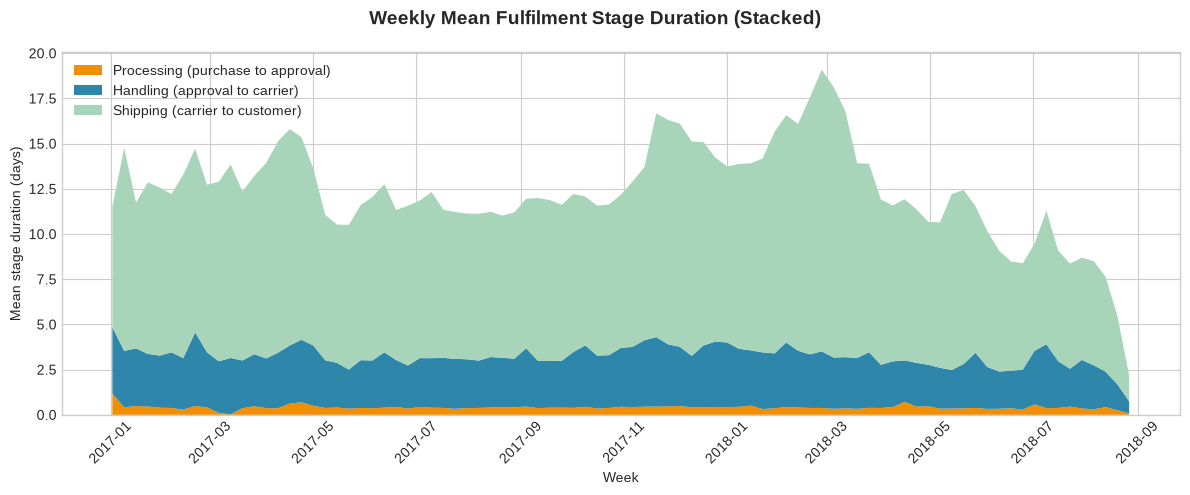

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Weekly Mean Fulfilment Stage Duration (Stacked)', fontsize=14, fontweight='bold')
stage_colors = ['#F18F01', '#2E86AB', '#A8D5BA']

ax.stackplot(stage_over_time.index, [stage_over_time[k] for k in STAGE_KEYS],
             labels=[STAGE_LABELS[k] for k in STAGE_KEYS], colors=stage_colors)
ax.set_xlabel('Week')
ax.set_ylabel('Mean stage duration (days)')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

**Finding:** Shipping (carrier to customer) dominates total lead time (~74% of the total on
average) vs. handling (~23%) and processing (~3%). Shipping is also the only stage whose duration
correlates meaningfully with weekly order volume &mdash; processing and handling don't. This points
to carrier/last-mile capacity, rather than internal order processing, as the main bottleneck
during high-demand periods.

---
## 10. Key Insights Summary

In [20]:
# Consolidated summary, same list-of-dicts -> DataFrame pattern as the starter notebook's
# schema_summary(), and dict-of-lists -> DataFrame pattern as its kpi_summary
capacity_kpi_summary = pd.DataFrame({
    'Metric': [
        'Volume-vs-delay correlation',
        'Delivery gap: Sunday vs Friday purchase',
        'Weekend handling-stage slowdown',
        'Freight-ratio vs late-rate range',
        'Peak backlog',
        'Promise-buffer vs trailing-actual correlation',
        'Shipping share of total lead time',
    ],
    'Value': [
        f"r = {corr:.2f}",
        f"{by_day.max() - by_day.min():.1f} days",
        f"{by_weekday_stage['handling_time'].max():.1f}d vs {by_weekday_stage['handling_time'].min():.1f}d",
        f"{freight_buckets['late_rate'].min():.1f}% - {freight_buckets['late_rate'].max():.1f}%",
        f"{peak_backlog['backlog']:.0f} orders",
        f"r = {corr_trailing:.2f}",
        f"{overall_mean['shipping_time'] / overall_mean.sum() * 100:.0f}%",
    ],
    'Implication': [
        'Delay is not purely volume-driven; effects are laggy and sustained',
        'Purchase timing is a free, zero-cost candidate feature',
        'Weekend slowdown is a warehouse queue issue, not a carrier issue',
        'This composite ratio is not a strong standalone predictor',
        'Backlog is a recurring, chronic condition, not just a holiday effect',
        "Olist's own 'late' label is a moving target over time",
        'Carrier/last-mile capacity is the main bottleneck under load',
    ],
})

print("=" * 100)
print("OPERATIONAL CAPACITY - KEY INSIGHTS SUMMARY")
print("=" * 100)
print(capacity_kpi_summary.to_string(index=False))
print("=" * 100)

OPERATIONAL CAPACITY - KEY INSIGHTS SUMMARY
                                       Metric        Value                                                          Implication
                  Volume-vs-delay correlation     r = 0.12   Delay is not purely volume-driven; effects are laggy and sustained
      Delivery gap: Sunday vs Friday purchase     1.6 days               Purchase timing is a free, zero-cost candidate feature
              Weekend handling-stage slowdown 3.7d vs 2.4d     Weekend slowdown is a warehouse queue issue, not a carrier issue
             Freight-ratio vs late-rate range  7.8% - 8.4%            This composite ratio is not a strong standalone predictor
                                 Peak backlog  4429 orders Backlog is a recurring, chronic condition, not just a holiday effect
Promise-buffer vs trailing-actual correlation     r = 0.45                Olist's own 'late' label is a moving target over time
            Shipping share of total lead time          74%  

### What this notebook found

1. Delay is systemic, not just per-order: backlog peaks *after* demand spikes, not during them,
   and stays elevated even in quiet periods &mdash; a chronic, not one-off, condition.
2. Purchase timing (day-of-week/hour) is a free, zero-leakage feature, and its effect traces to
   a specific pipeline stage (handling, not shipping).
3. Total lead time is dominated by shipping/carrier transit (~74%), and it's the only stage whose
   duration correlates with order volume &mdash; the bottleneck under demand pressure is the carrier
   network, not internal processing.
4. Olist's own delivery promise is not a fixed reference point; it drifts with a lag, which has
   direct implications for how the "late" classification target should be defined in Phase 2.

**Candidate problems this supports:** delivery lead-time regression + late/on-time classification
(Problem 1), and provides a leading feature (predicted delay) for review-score classification
(Problem 2).